# 12장 실습 — Population Coding

**Spiking Neural Networks 쿡북 with Python** · 12장 실습 노트북

클래스마다 출력 뉴런을 여러 개 두는 **인구 코딩**으로 분류한다. 단일 출력 모델과 정확도를 비교한다.

### 학습 목표
- 단일 출력(10개)과 인구 출력(500개) 두 네트워크를 만든다.
- `population_code=True` 옵션으로 손실·정확도를 집계한다.
- 두 방식의 테스트 정확도를 비교한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import utils
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)
device = torch.device('cpu')
batch_size = 128

## 2. 데이터 준비 (Fashion-MNIST)

조금 더 어려운 Fashion-MNIST로 차이를 본다. 일부만 사용해 빠르게 학습한다.

In [2]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0,), (1,))])
fmnist_train = datasets.FashionMNIST('/tmp/data/fmnist', train=True, download=True, transform=transform)
fmnist_test = datasets.FashionMNIST('/tmp/data/fmnist', train=False, download=True, transform=transform)
fmnist_train = utils.data_subset(fmnist_train, subset=20)

train_loader = DataLoader(fmnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(fmnist_test, batch_size=batch_size, shuffle=True, drop_last=True)
print('학습 샘플 수:', len(fmnist_train))

100%|███████████████████████████████████████| 26.4M/26.4M [01:32<00:00, 286kB/s]
100%|███████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 140kB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:02<00:00, 2.20MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 4.79MB/s]

학습 샘플 수: 3000


## 3. 두 네트워크 정의 — 단일 출력 vs 인구 출력

구조는 같고 **출력 뉴런 수만** 다르다. 단일 출력은 10개, 인구 출력은 클래스당 50개씩 500개다.

In [3]:
num_inputs = 28 * 28
num_hidden = 128
beta = 0.9
grad = surrogate.fast_sigmoid()

def make_net(num_outputs):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(num_inputs, num_hidden),
        snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True),
        nn.Linear(num_hidden, num_outputs),
        snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True, output=True),
    ).to(device)

net = make_net(10)              # 단일 출력 (클래스당 1개)
net_pop = make_net(500)         # 인구 출력 (클래스당 50개)
print('단일 출력 뉴런:', 10, '| 인구 출력 뉴런:', 500)

단일 출력 뉴런: 10 | 인구 출력 뉴런: 500


## 4. 시간 전개 순전파와 학습 함수

순전파 함수와 학습 함수를 정의한다. 손실의 `population_code` 옵션만 바꾸면 같은 코드로 두 방식을 학습할 수 있다.

In [4]:
num_steps = 10

def forward_pass(net, data):
    utils.reset(net)
    spk_rec = []
    for step in range(num_steps):
        spk_out, _ = net(data)
        spk_rec.append(spk_out)
    return torch.stack(spk_rec)

def train(net, loss_fn):
    optimizer = torch.optim.Adam(net.parameters(), lr=2e-3, betas=(0.9, 0.999))
    net.train()
    for data, targets in train_loader:
        data = data.to(device); targets = targets.to(device)
        spk_rec = forward_pass(net, data)
        loss_val = loss_fn(spk_rec, targets)
        optimizer.zero_grad(); loss_val.backward(); optimizer.step()
    print('학습 완료 — 마지막 배치 손실:', round(loss_val.item(), 3))

## 5. 정확도 함수

정확도 함수는 `SF.accuracy_rate`의 추가 인자를 그대로 전달받는다. 인구 코딩일 때는 `population_code=True, num_classes=10`을 넘긴다.

In [5]:
def test_accuracy(net, loader, **acc_kwargs):
    total = 0
    acc = 0.0
    net.eval()
    with torch.no_grad():
        for data, targets in loader:
            data = data.to(device); targets = targets.to(device)
            spk_rec = forward_pass(net, data)
            acc += SF.accuracy_rate(spk_rec, targets, **acc_kwargs) * spk_rec.size(1)
            total += spk_rec.size(1)
    return acc / total

## 6. 두 방식 학습·비교

단일 출력과 인구 출력을 각각 학습하고 테스트 정확도를 비교한다. 인구 코딩 쪽 손실·정확도에는 `population_code=True`를 지정한다.

In [6]:
# 단일 출력 학습
loss_single = SF.mse_count_loss(correct_rate=1.0, incorrect_rate=0.0)
train(net, loss_single)
acc_single = test_accuracy(net, test_loader)

# 인구 출력 학습 (population_code 지정)
loss_pop = SF.mse_count_loss(correct_rate=1.0, incorrect_rate=0.0, population_code=True, num_classes=10)
train(net_pop, loss_pop)
acc_pop = test_accuracy(net_pop, test_loader, population_code=True, num_classes=10)

print(f'단일 출력 정확도: {acc_single*100:.2f}%')
print(f'인구 코딩 정확도: {acc_pop*100:.2f}%')

학습 완료 — 마지막 배치 손실: 0.485
학습 완료 — 마지막 배치 손실: 1366.627
단일 출력 정확도: 66.07%
인구 코딩 정확도: 66.46%


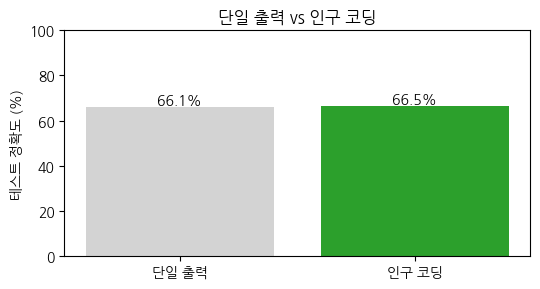

In [7]:
plt.figure(figsize=(5.5, 3))
bars = plt.bar(
    ['단일 출력', '인구 코딩'], 
    [acc_single*100, acc_pop*100], 
    color=['lightgray', 'tab:green']
)
plt.bar_label(bars, fmt='%.1f%%')
plt.ylabel('테스트 정확도 (%)'); plt.title('단일 출력 vs 인구 코딩')
plt.ylim(0, 100); plt.tight_layout(); plt.show()

## 정리

- 인구 코딩은 클래스당 출력 뉴런을 여러 개 둔다(여기서는 50개씩 500개).
- `population_code=True, num_classes=10`만 지정하면 집계가 자동 처리된다.
- 보통 인구 코딩이 더 높은 정확도와 강건성을 보인다.

이로써 4부 실전 레시피를 마친다. 5부에서는 상태공간 SNN·이진화·NIR 등 심화 주제로 나아간다.